In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

df = pd.read_csv("lmu_muenchen_2005_2025_clean.csv",
                 index_col="Datum",
                 parse_dates=True)

print(df.shape)
df.head()

(7670, 7)


,T_max,T_min,Regen,p_max,p_min,Sonne,ist_interpoliert
Datum,,,,,,,
2005-01-01,7.3,3.2,0.0,966.1,961.0,1.4,0
2005-01-02,8.0,1.2,1.0,967.8,957.6,0.0,0
2005-01-03,4.0,1.4,0.1,972.6,967.8,0.0,0
2005-01-04,6.8,3.3,0.0,971.1,967.3,4.3,0
2005-01-05,8.0,2.7,0.0,969.0,964.1,2.2,0


       hitzetag  heisser_tag  frosttag  eistag  starkregen
Datum                                                     
2005          5            0        80      38           3
2006          9            0        78      32           1
2007          4            0        45      17           7
2008          7            0        63      11           4
2009          7            0        73      31           2
2010         10            0        89      54           4
2011          8            1        59      18           4
2012         12            1        64      25           6
2013         13            1        80      28           5
2014          7            0        27       4           2
2015         23            0        55       7           4
2016          7            0        52       8           3
2017         19            1        63      23           0
2018         13            0        65      18           2
2019          9            0        48      12          

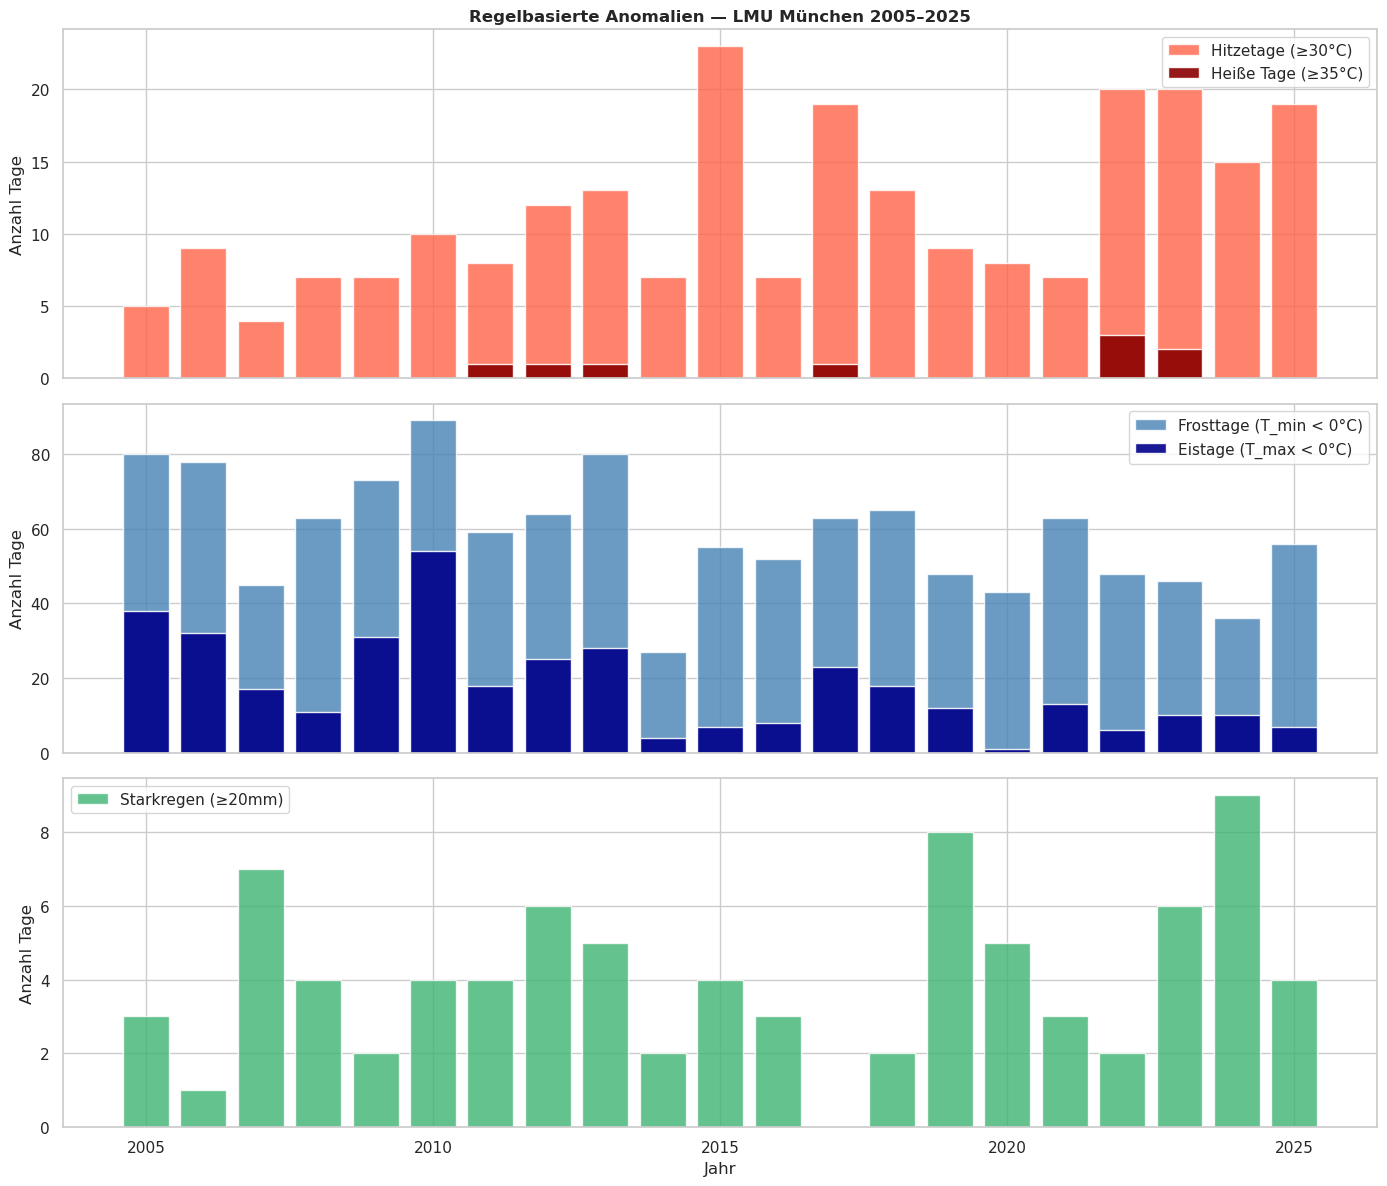

In [2]:
# ── Phase 5.1 — Regelbasierte Anomalien ─────────────────────────
# DWD-Definitionen
df["hitzetag"]    = (df["T_max"] >= 30).astype(int)
df["heisser_tag"] = (df["T_max"] >= 35).astype(int)
df["frosttag"]    = (df["T_min"] <   0).astype(int)
df["eistag"]      = (df["T_max"] <   0).astype(int)
df["starkregen"]  = (df["Regen"] >= 20).astype(int)

# Übersicht pro Jahr
jahres_stats = df.groupby(df.index.year)[
    ["hitzetag", "heisser_tag", "frosttag", "eistag", "starkregen"]
].sum()

print(jahres_stats.to_string())

# ── Visualisierung ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].bar(jahres_stats.index, jahres_stats["hitzetag"],
            color="tomato", alpha=0.8, label="Hitzetage (≥30°C)")
axes[0].bar(jahres_stats.index, jahres_stats["heisser_tag"],
            color="darkred", alpha=0.9, label="Heiße Tage (≥35°C)")
axes[0].set_ylabel("Anzahl Tage")
axes[0].set_title("Regelbasierte Anomalien — LMU München 2005–2025",
                  fontweight="bold")
axes[0].legend()

axes[1].bar(jahres_stats.index, jahres_stats["frosttag"],
            color="steelblue", alpha=0.8, label="Frosttage (T_min < 0°C)")
axes[1].bar(jahres_stats.index, jahres_stats["eistag"],
            color="darkblue", alpha=0.9, label="Eistage (T_max < 0°C)")
axes[1].set_ylabel("Anzahl Tage")
axes[1].legend()

axes[2].bar(jahres_stats.index, jahres_stats["starkregen"],
            color="mediumseagreen", alpha=0.8, label="Starkregen (≥20mm)")
axes[2].set_ylabel("Anzahl Tage")
axes[2].set_xlabel("Jahr")
axes[2].legend()

plt.tight_layout()
plt.show()

Anomalien gesamt: 2

Anomalien pro Jahr:
Datum
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    1
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    1
2023    0
2024    0
2025    0


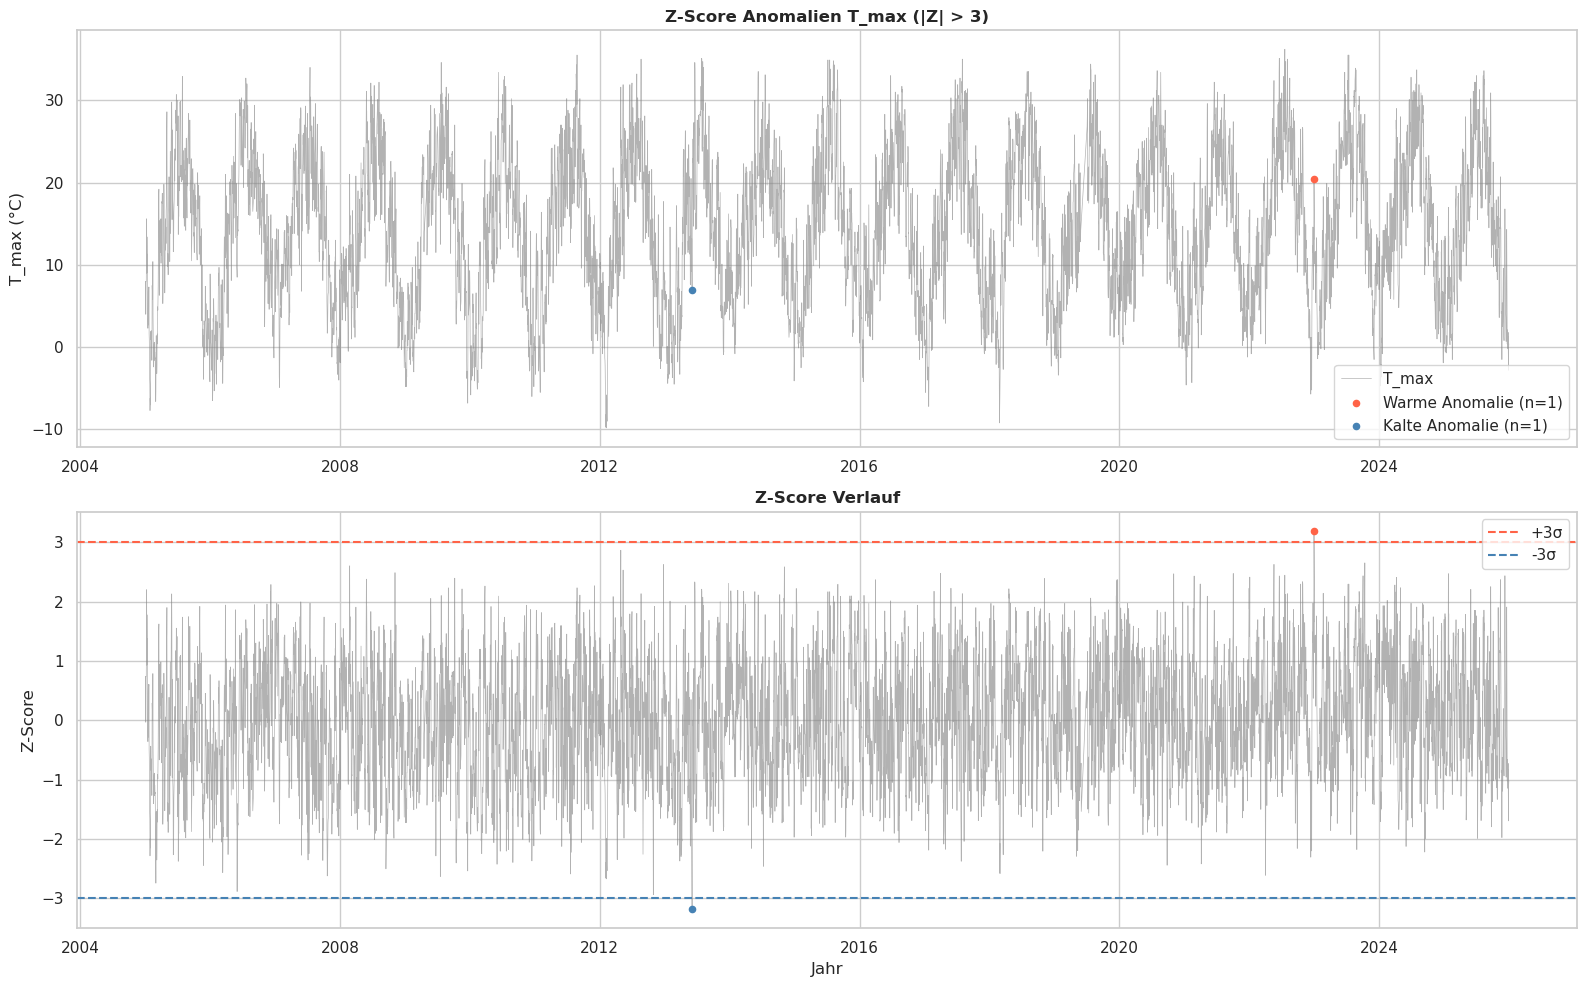

In [3]:
# ── Phase 5.2 — Z-Score Anomalieerkennung ───────────────────────
from scipy import stats

# Z-Score relativ zum Monatsmittel berechnen
# (nicht zum Gesamtmittel — saisonaler Kontext!)
df["T_max_zscore"] = df.groupby(df.index.month)["T_max"].transform(
    lambda x: stats.zscore(x)
)

# Anomalien definieren: |Z| > 3
df["anomalie_zscore"] = (df["T_max_zscore"].abs() > 3).astype(int)

print(f"Anomalien gesamt: {df['anomalie_zscore'].sum()}")
print(f"\nAnomalien pro Jahr:")
print(df.groupby(df.index.year)["anomalie_zscore"].sum().to_string())

# ── Visualisierung ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Zeitreihe mit markierten Anomalien
anomalien = df[df["anomalie_zscore"] == 1]
warm = anomalien[anomalien["T_max_zscore"] > 0]
kalt = anomalien[anomalien["T_max_zscore"] < 0]

axes[0].plot(df.index, df["T_max"],
             color="gray", linewidth=0.5, alpha=0.6, label="T_max")
axes[0].scatter(warm.index, warm["T_max"],
                color="tomato", s=20, zorder=5, label=f"Warme Anomalie (n={len(warm)})")
axes[0].scatter(kalt.index, kalt["T_max"],
                color="steelblue", s=20, zorder=5, label=f"Kalte Anomalie (n={len(kalt)})")
axes[0].set_title("Z-Score Anomalien T_max (|Z| > 3)", fontweight="bold")
axes[0].set_ylabel("T_max (°C)")
axes[0].legend()

# Plot 2: Z-Score Zeitreihe
axes[1].plot(df.index, df["T_max_zscore"],
             color="gray", linewidth=0.5, alpha=0.6)
axes[1].axhline(3,  color="tomato",    linestyle="--", linewidth=1.5, label="+3σ")
axes[1].axhline(-3, color="steelblue", linestyle="--", linewidth=1.5, label="-3σ")
axes[1].scatter(warm.index, warm["T_max_zscore"],
                color="tomato", s=20, zorder=5)
axes[1].scatter(kalt.index, kalt["T_max_zscore"],
                color="steelblue", s=20, zorder=5)
axes[1].set_title("Z-Score Verlauf", fontweight="bold")
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Jahr")
axes[1].legend()

plt.tight_layout()
plt.show()

Anomalien gesamt (rollierend): 0

Anomалien pro Jahr:
Datum
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
2025    0


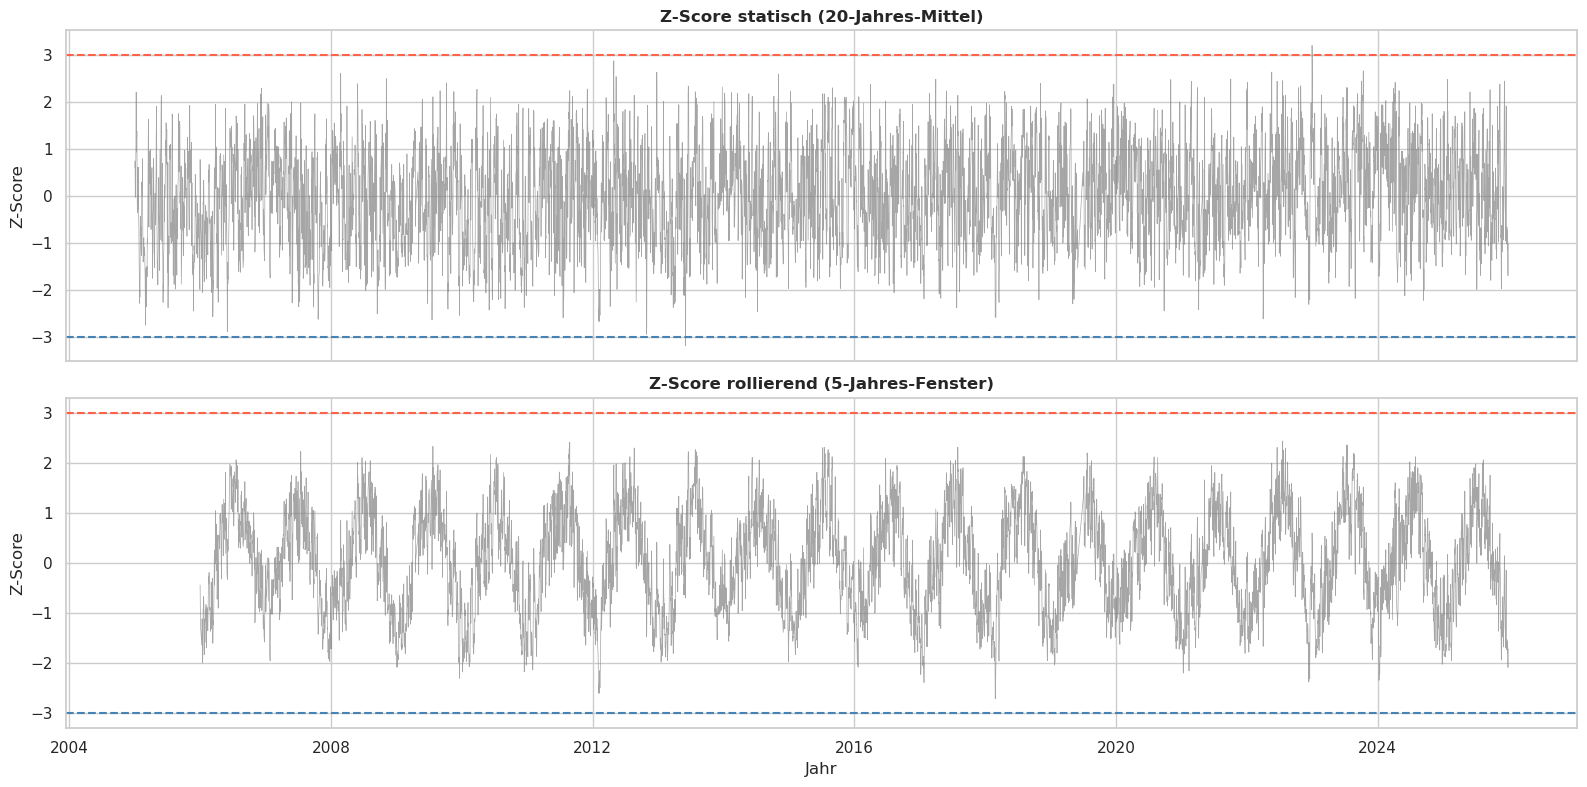

In [4]:
# ── Z-Score mit rollierender Baseline (5 Jahre) ─────────────────
roll_mean = df["T_max"].rolling(window=365*5, min_periods=365).mean()
roll_std  = df["T_max"].rolling(window=365*5, min_periods=365).std()

df["T_max_zscore_roll"] = (df["T_max"] - roll_mean) / roll_std
df["anomalie_zscore_roll"] = (df["T_max_zscore_roll"].abs() > 3).astype(int)

print(f"Anomalien gesamt (rollierend): {df['anomalie_zscore_roll'].sum()}")
print(f"\nAnomалien pro Jahr:")
print(df.groupby(df.index.year)["anomalie_zscore_roll"].sum().to_string())

# Vergleich: statisch vs. rollierend
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df["T_max_zscore"],
             color="gray", linewidth=0.5, alpha=0.7)
axes[0].axhline(3,  color="tomato",    linestyle="--", linewidth=1.5)
axes[0].axhline(-3, color="steelblue", linestyle="--", linewidth=1.5)
axes[0].set_title("Z-Score statisch (20-Jahres-Mittel)", fontweight="bold")
axes[0].set_ylabel("Z-Score")

axes[1].plot(df.index, df["T_max_zscore_roll"],
             color="gray", linewidth=0.5, alpha=0.7)
axes[1].axhline(3,  color="tomato",    linestyle="--", linewidth=1.5)
axes[1].axhline(-3, color="steelblue", linestyle="--", linewidth=1.5)
axes[1].set_title("Z-Score rollierend (5-Jahres-Fenster)", fontweight="bold")
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Jahr")

plt.tight_layout()
plt.show()

Anomalien gesamt (|Z|>2): 245
Davon warm: 124  |  kalt: 121

Anomалien pro Jahr:
Datum
2005    13
2006     9
2007    10
2008     8
2009    13
2010    23
2011     8
2012    21
2013    23
2014    12
2015    13
2016     4
2017    10
2018    12
2019     7
2020     2
2021     9
2022    19
2023    14
2024     9
2025     6


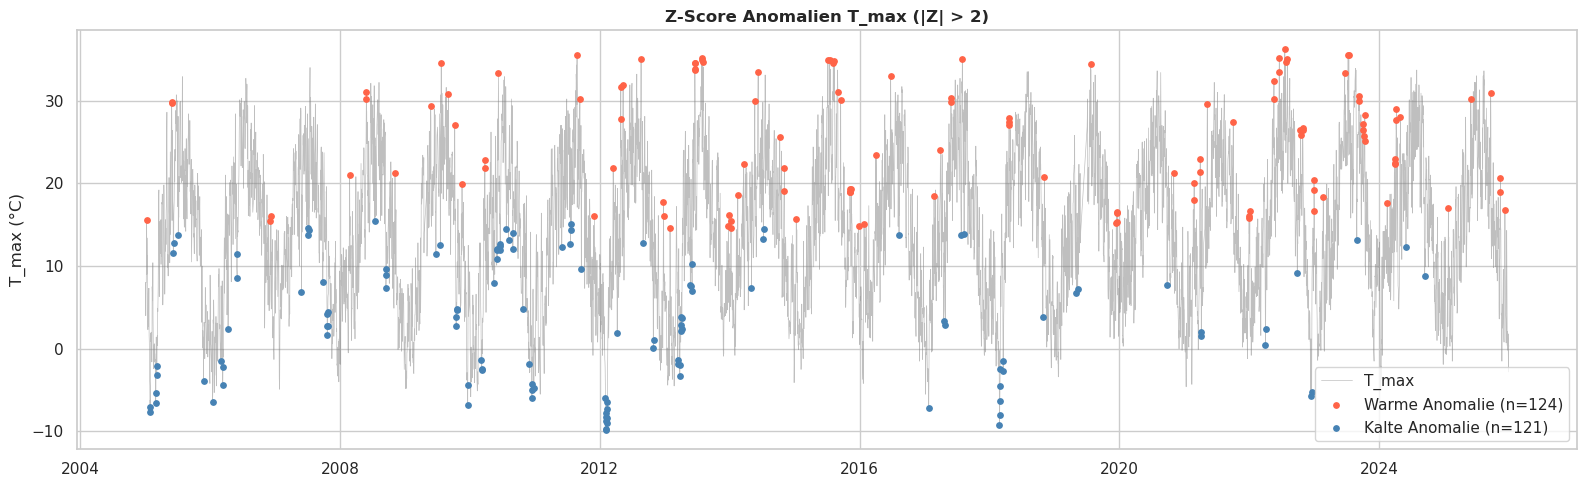

In [5]:
# ── Option A — Z-Score mit |Z| > 2 ──────────────────────────────
df["anomalie_z2"] = (df["T_max_zscore"].abs() > 2).astype(int)
warm_z2 = df[(df["anomalie_z2"] == 1) & (df["T_max_zscore"] > 0)]
kalt_z2 = df[(df["anomalie_z2"] == 1) & (df["T_max_zscore"] < 0)]

print(f"Anomalien gesamt (|Z|>2): {df['anomalie_z2'].sum()}")
print(f"Davon warm: {len(warm_z2)}  |  kalt: {len(kalt_z2)}")
print(f"\nAnomалien pro Jahr:")
print(df.groupby(df.index.year)["anomalie_z2"].sum().to_string())

# Visualisierung
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["T_max"],
        color="gray", linewidth=0.5, alpha=0.5, label="T_max")
ax.scatter(warm_z2.index, warm_z2["T_max"],
           color="tomato", s=15, zorder=5,
           label=f"Warme Anomalie (n={len(warm_z2)})")
ax.scatter(kalt_z2.index, kalt_z2["T_max"],
           color="steelblue", s=15, zorder=5,
           label=f"Kalte Anomalie (n={len(kalt_z2)})")
ax.set_title("Z-Score Anomalien T_max (|Z| > 2)", fontweight="bold")
ax.set_ylabel("T_max (°C)")
ax.legend()
plt.tight_layout()
plt.show()

Anomalien gesamt (Isolation Forest): 231

Anomалien pro Jahr:
Datum
2005     9
2006     8
2007     7
2008    10
2009    14
2010    19
2011     4
2012    18
2013    14
2014     4
2015    11
2016     7
2017    10
2018     4
2019    18
2020    15
2021    10
2022     6
2023    18
2024    15
2025    10


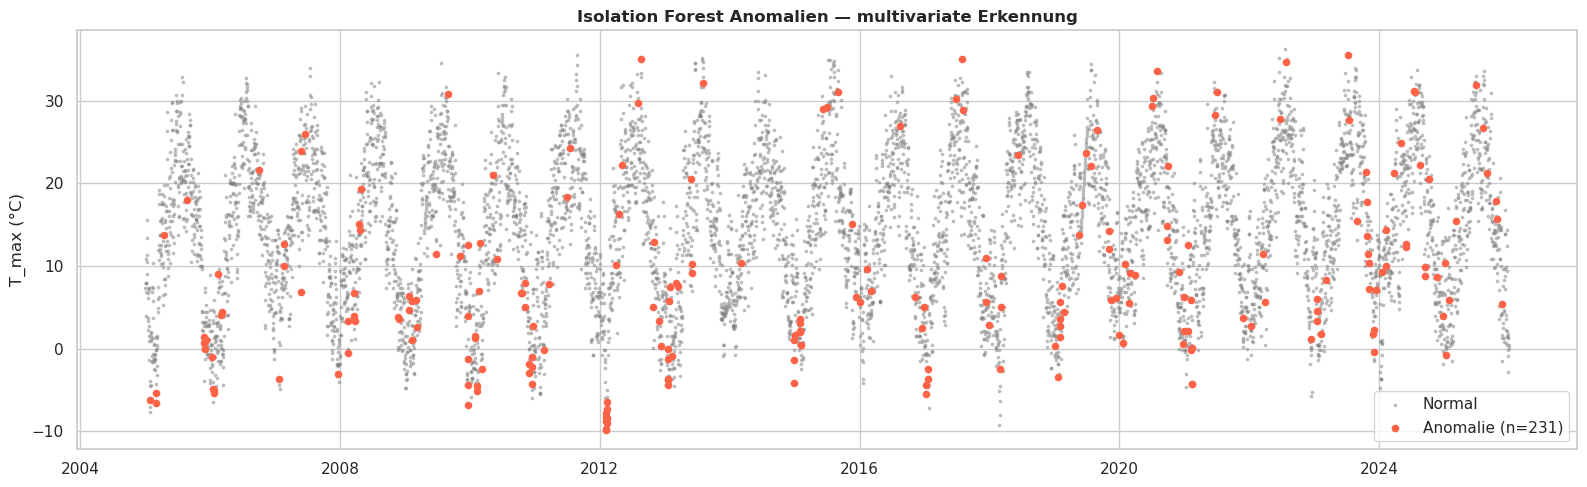

In [6]:
# ── Option B — Isolation Forest ─────────────────────────────────
from sklearn.ensemble import IsolationForest

# Features für den Isolation Forest
features_if = df[["T_max", "T_min", "Regen",
                   "p_max", "p_min", "Sonne"]].copy()

# Modell trainieren
iso = IsolationForest(contamination=0.03,  # erwartet ~3% Anomalien
                      random_state=42)
df["anomalie_if"] = iso.fit_predict(features_if)

# fit_predict gibt -1 für Anomalie, 1 für normal zurück
df["anomalie_if"] = (df["anomalie_if"] == -1).astype(int)

print(f"Anomalien gesamt (Isolation Forest): {df['anomalie_if'].sum()}")
print(f"\nAnomалien pro Jahr:")
print(df.groupby(df.index.year)["anomalie_if"].sum().to_string())

# Visualisierung
fig, ax = plt.subplots(figsize=(16, 5))
normal   = df[df["anomalie_if"] == 0]
anomal   = df[df["anomalie_if"] == 1]

ax.scatter(normal.index, normal["T_max"],
           color="gray", s=3, alpha=0.4, label="Normal")
ax.scatter(anomal.index, anomal["T_max"],
           color="tomato", s=20, zorder=5,
           label=f"Anomalie (n={len(anomal)})")
ax.set_title("Isolation Forest Anomalien — multivariate Erkennung",
             fontweight="bold")
ax.set_ylabel("T_max (°C)")
ax.legend()
plt.tight_layout()
plt.show()

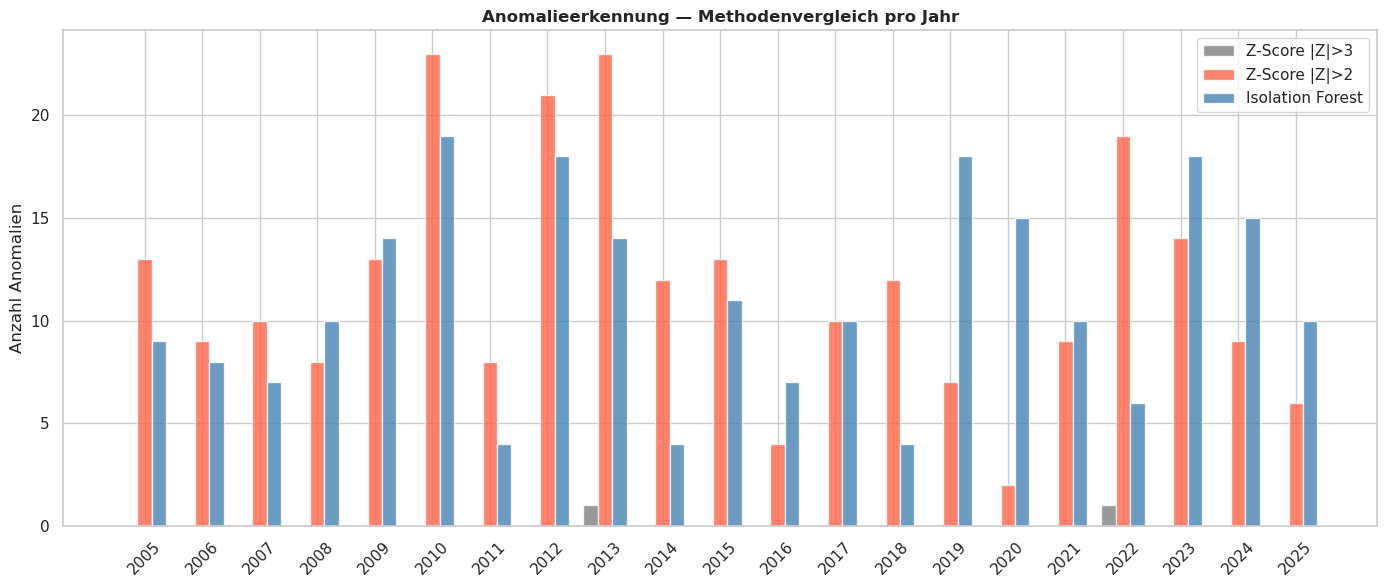

In [7]:
# ── Methodenvergleich ────────────────────────────────────────────
jahres_vergleich = pd.DataFrame({
    "Z-Score |Z|>3" : df.groupby(df.index.year)["anomalie_zscore"].sum(),
    "Z-Score |Z|>2" : df.groupby(df.index.year)["anomalie_z2"].sum(),
    "Isolation Forest": df.groupby(df.index.year)["anomalie_if"].sum(),
})

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(jahres_vergleich))
breite = 0.25

ax.bar(x - breite, jahres_vergleich["Z-Score |Z|>3"],
       breite, color="gray", alpha=0.8, label="Z-Score |Z|>3")
ax.bar(x, jahres_vergleich["Z-Score |Z|>2"],
       breite, color="tomato", alpha=0.8, label="Z-Score |Z|>2")
ax.bar(x + breite, jahres_vergleich["Isolation Forest"],
       breite, color="steelblue", alpha=0.8, label="Isolation Forest")

ax.set_xticks(x)
ax.set_xticklabels(jahres_vergleich.index, rotation=45)
ax.set_title("Anomalieerkennung — Methodenvergleich pro Jahr",
             fontweight="bold")
ax.set_ylabel("Anzahl Anomalien")
ax.legend()
plt.tight_layout()
plt.show()